In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [68]:
df = pd.read_csv('data.csv', sep=',')
df.head()

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0


In [69]:
df.shape

(14412, 2)

In [70]:
df['toxic'] = df['toxic'].apply(int)

In [71]:
df.head()

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\n",1
1,"Хохлы, это отдушина затюканого россиянина, мол...",1
2,Собаке - собачья смерть\n,1
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1


In [72]:
df['toxic'].value_counts()

toxic
0    9586
1    4826
Name: count, dtype: int64

In [73]:
for c in df[df['toxic'] == 1].head(5)['comment']:
    print(c)

Верблюдов-то за что? Дебилы, бл...

Хохлы, это отдушина затюканого россиянина, мол, вон, а у хохлов еще хуже. Если бы хохлов не было, кисель их бы придумал.

Собаке - собачья смерть

Страницу обнови, дебил. Это тоже не оскорбление, а доказанный факт - не-дебил про себя во множественном числе писать не будет. Или мы в тебя верим - это ты и твои воображаемые друзья?

тебя не убедил 6-страничный пдф в том, что Скрипалей отравила Россия? Анализировать и думать пытаешься? Ватник что ли?)



In [74]:
for c in df[df['toxic'] == 0].head(5)['comment']:
    print(c)

В шапке были ссылки на инфу по текущему фильму марвел. Эти ссылки были заменены на фразу Репортим брипидора, игнорируем его посты. Если этого недостаточно, чтобы понять, что модератор абсолютный неадекват, и его нужно лишить полномочий, тогда эта борда пробивает абсолютное дно по неадекватности.

Почитайте посты у этого автора,может найдете что нибудь полезное. Надеюсь помог) https: pikabu.ru story obyichnyie budni dezsluzhbyi 4932098

Про графику было обидно) я так то проходил все серии гта со второй части по пятую, кроме гта 4. И мне не мешала графика ни в одной из частей. На компе у меня было куча видеокарт. Начиная с 32мб RIVA TNT и заканчивая 2Гб 560Ti на которой я спокойно играю который год в танки, гта5, ведьмака3 купил на распродаже и начал проходить. Да, не на ультрах. С пониженными текстурами. И не мешает. Я не понимаю дрочева на графике, требовать графику уровня плойки 4 минимум. Мне надо чтобы глаза не резало, только и всего. По поводу управления, мне не хватает переходника

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
train_df, test_df = train_test_split(df, test_size=500)

In [77]:
train_df['toxic'].value_counts()

toxic
0    9245
1    4667
Name: count, dtype: int64

In [78]:
test_df['toxic'].value_counts()

toxic
0    341
1    159
Name: count, dtype: int64

## Очистка данных (приведение к нижнему регистру, удаление пунктуации, удаление цифр)

In [79]:
import re



def cleaner(text):
    text = text.lower()
    text = re.sub(r'[^a-zа-яё\s]', '', text)  # оставляем только буквы и пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [80]:
train_df['comment'] = train_df['comment'].apply(cleaner)

In [81]:
train_df['comment'].head()

768      хоть ты и дегенерат но ты прав в том что ты гр...
13364    хмм у меня телефон сам пробелы в большинстве с...
13824    малолетние дебилы не знающие когда появилась ц...
5861     рашкапарашка as is не хватает только переимено...
895      видимо не приписывала по крайней мере для пенс...
Name: comment, dtype: str

In [82]:
test_df['comment'] = test_df['comment'].apply(cleaner)

In [83]:
test_df['comment'].head()

10430    а уверен что это зенитные батареи а не надувна...
8192     у вас либо золото хреновое либо букеты из ален...
12928    это смело это как в гомосексуализме признаться...
9375     да тут же вся суть была именно в описании проц...
8231     да и так видно что сэс не эффективна по вложен...
Name: comment, dtype: str

## Токенизация. Исользуется библиотека "razdel" в целях лучшей работы с русским текстом

In [84]:
from razdel import tokenize


def tokenize_text(text):
    return [token.text for token in tokenize(text)]

In [85]:
train_df['tokens'] = train_df['comment'].apply(tokenize_text)
test_df['tokens'] = test_df['comment'].apply(tokenize_text)

In [86]:
train_df.head()

,comment,toxic,tokens
768,хоть ты и дегенерат но ты прав в том что ты гр...,1,"[хоть, ты, и, дегенерат, но, ты, прав, в, том,..."
13364,хмм у меня телефон сам пробелы в большинстве с...,0,"[хмм, у, меня, телефон, сам, пробелы, в, больш..."
13824,малолетние дебилы не знающие когда появилась ц...,1,"[малолетние, дебилы, не, знающие, когда, появи..."
5861,рашкапарашка as is не хватает только переимено...,1,"[рашкапарашка, as, is, не, хватает, только, пе..."
895,видимо не приписывала по крайней мере для пенс...,0,"[видимо, не, приписывала, по, крайней, мере, д..."


## Лемматизация

In [87]:
import pymorphy2


morph = pymorphy2.MorphAnalyzer()

def lemmatize(tokens):
    return [morph.parse(token)[0].normal_form for token in tokens]

In [88]:
train_df['tokens'] = train_df['tokens'].apply(lemmatize)
test_df['tokens'] = test_df['tokens'].apply(lemmatize)

In [89]:
train_df.head()

,comment,toxic,tokens
768,хоть ты и дегенерат но ты прав в том что ты гр...,1,"[хоть, ты, и, дегенерат, но, ты, право, в, тот..."
13364,хмм у меня телефон сам пробелы в большинстве с...,0,"[хмм, у, я, телефон, сам, пробел, в, большинст..."
13824,малолетние дебилы не знающие когда появилась ц...,1,"[малолетний, дебил, не, знающий, когда, появит..."
5861,рашкапарашка as is не хватает только переимено...,1,"[рашкапарашка, as, is, не, хватать, только, пе..."
895,видимо не приписывала по крайней мере для пенс...,0,"[видимо, не, приписывать, по, крайний, мера, д..."


## Собираем обратно в слова

In [90]:
train_df['text_final'] = train_df['tokens'].apply(lambda x: ' '.join(x))
test_df['text_final'] = test_df['tokens'].apply(lambda x: ' '.join(x))

In [91]:
train_df.head()

,comment,toxic,tokens,text_final
768,хоть ты и дегенерат но ты прав в том что ты гр...,1,"[хоть, ты, и, дегенерат, но, ты, право, в, тот...",хоть ты и дегенерат но ты право в тот что ты г...
13364,хмм у меня телефон сам пробелы в большинстве с...,0,"[хмм, у, я, телефон, сам, пробел, в, большинст...",хмм у я телефон сам пробел в большинство свой ...
13824,малолетние дебилы не знающие когда появилась ц...,1,"[малолетний, дебил, не, знающий, когда, появит...",малолетний дебил не знающий когда появиться цв...
5861,рашкапарашка as is не хватает только переимено...,1,"[рашкапарашка, as, is, не, хватать, только, пе...",рашкапарашка as is не хватать только переимено...
895,видимо не приписывала по крайней мере для пенс...,0,"[видимо, не, приписывать, по, крайний, мера, д...",видимо не приписывать по крайний мера для пенс...


## Используем TF-IDF меру для оценки важности слова
- TF (Term Frequency) показывает, насколько часто слово встречается $$TF = (количество вхождений слова)/(общее количество слов)$$
- IDF (Inverse Document Frequency) понижает вес слов, которые встречаются почти везде $$IDF = log((общее количество документов)/(кол-во документов с этим словом))$$



In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))

In [93]:
X_train = vectorizer.fit_transform(train_df['text_final'])
X_test = vectorizer.transform(test_df['text_final'])

In [94]:
y_train = train_df['toxic']
y_test = test_df['toxic']

## Выбор модели. Выбор между LogisticRegression, LinearSVC, MultinomialNB

In [95]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score



models = {
    "SVM": LinearSVC(class_weight='balanced'),
    "LogReg": LogisticRegression(max_iter=1000),
    "NaiveBayes": MultinomialNB()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, f1_score(y_test, y_pred))

SVM 0.7191011235955056
LogReg 0.7205387205387206
NaiveBayes 0.6539923954372624


## Выбрана модель Логистической регрессии

In [96]:
def preprocess_text(text):
    # lowercase
    text = text.lower()

    # удаляем всё кроме букв
    text = re.sub(r'[^a-zа-яё\s]', '', text)

    # убираем лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    # токенизация
    tokens = [token.text for token in tokenize(text)]

    # лемматизация
    lemmas = [morph.parse(token)[0].normal_form for token in tokens]

    return lemmas

In [97]:
from sklearn.pipeline import Pipeline



model_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        tokenizer=preprocess_text,
        token_pattern=None,
        max_features=10000,
        ngram_range=(1, 2)
    )),

    ('model', LogisticRegression(
        random_state=0,
        max_iter=1000
    ))
])

In [98]:
model_pipeline.fit(
    train_df['comment'],
    train_df['toxic']
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<function pre...t 0x14b1ac0e0>


In [99]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve
)


def evaluate_model(model, X_test, y_test):

    # предсказания
    y_pred = model.predict(X_test)

    # вероятности
    y_proba = model.predict_proba(X_test)[:, 1]

    # текстовые метрики
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6, 6))

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title("Confusion Matrix")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 5))

    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')

    plt.legend()

    plt.show()

    precision, recall, _ = precision_recall_curve(y_test, y_proba)

    plt.figure(figsize=(7, 5))

    plt.plot(recall, precision)

    plt.xlabel('Recall')
    plt.ylabel('Precision')

    plt.title('Precision-Recall Curve')

    plt.show()

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       341
           1       0.86      0.67      0.76       159

    accuracy                           0.86       500
   macro avg       0.86      0.81      0.83       500
weighted avg       0.86      0.86      0.86       500



<Figure size 600x600 with 0 Axes>

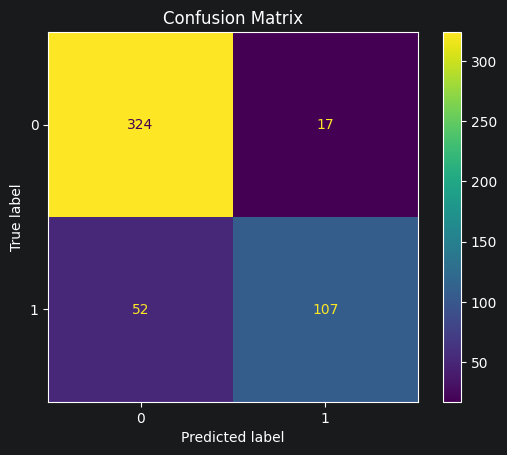

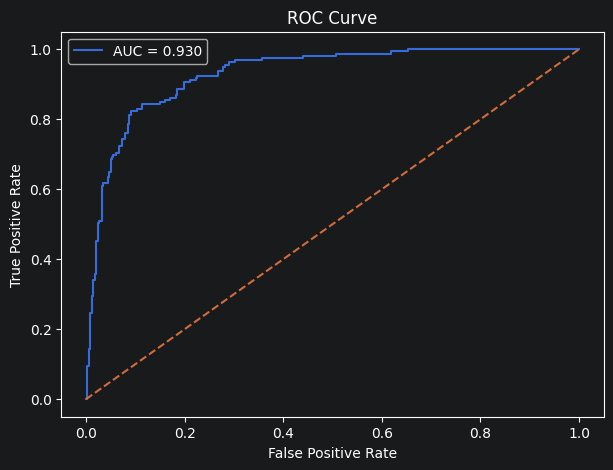

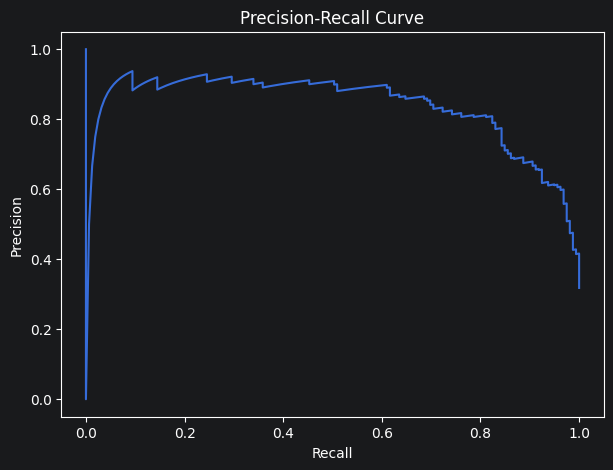

In [100]:
evaluate_model(
    model_pipeline,
    test_df['comment'],
    test_df['toxic']
)

## Проверка модели на других тестовых данных

In [101]:
test_comments = [
    # хорошие
    ("Спасибо большое за помощь!", 0),
    ("Очень полезная статья", 0),
    ("Ты молодец, продолжай в том же духе", 0),
    ("Мне понравилось читать этот материал", 0),
    ("Хорошая работа", 0),
    ("Отличное объяснение темы", 0),
    ("Было интересно", 0),
    ("Удачи тебе в проекте", 0),

    # токсичные
    ("Ты вообще идиот", 1),
    ("Какой же ты тупой", 1),
    ("Это полный бред", 1),
    ("Автор несет чушь", 1),
    ("Ты отвратительный человек", 1),
    ("Закрой рот уже", 1),
    ("Ненавижу таких людей", 1),
    ("Иди отсюда", 1),
]

In [102]:
for text, true_label in test_comments:

    pred = model_pipeline.predict([text])[0]
    proba = model_pipeline.predict_proba([text])[0]

    print(f"\nКомментарий: {text}")
    print(f"Истинная метка: {true_label}")
    print(f"Предсказание: {pred}")
    print(f"Уверенность: {max(proba):.3f}")


Комментарий: Спасибо большое за помощь!
Истинная метка: 0
Предсказание: 0
Уверенность: 0.918

Комментарий: Очень полезная статья
Истинная метка: 0
Предсказание: 0
Уверенность: 0.920

Комментарий: Ты молодец, продолжай в том же духе
Истинная метка: 0
Предсказание: 1
Уверенность: 0.734

Комментарий: Мне понравилось читать этот материал
Истинная метка: 0
Предсказание: 0
Уверенность: 0.655

Комментарий: Хорошая работа
Истинная метка: 0
Предсказание: 0
Уверенность: 0.901

Комментарий: Отличное объяснение темы
Истинная метка: 0
Предсказание: 0
Уверенность: 0.693

Комментарий: Было интересно
Истинная метка: 0
Предсказание: 0
Уверенность: 0.866

Комментарий: Удачи тебе в проекте
Истинная метка: 0
Предсказание: 1
Уверенность: 0.663

Комментарий: Ты вообще идиот
Истинная метка: 1
Предсказание: 1
Уверенность: 0.940

Комментарий: Какой же ты тупой
Истинная метка: 1
Предсказание: 1
Уверенность: 0.977

Комментарий: Это полный бред
Истинная метка: 1
Предсказание: 1
Уверенность: 0.509

Комментарий: А